# 2 — Classical Source Inversion
## Stage 2 · Solving `C = T · Q` with Classical Linear Methods
> Loads artefacts produced by **1-transport-matrix.ipynb** and solves for the
> emission rate vector **Q** using four classical inversion techniques.
>
> | Method | Key property |
> |---|---|
> | Least Squares (`lstsq`) | Unconstrained minimum-norm solution |
> | NNLS | Non-negative — physically meaningful Q ≥ 0 |
> | Tikhonov (Ridge) | L2 regularisation — stable under ill-conditioning |
> | Truncated SVD | Low-rank approximation — noise-filtering |


---

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 0 — GLOBAL STYLE CONFIGURATION
# What: Identical one-time theme to notebook 1 for visual consistency.
# Why:  Centralised — no per-plot style parameters anywhere in this notebook.
# ─────────────────────────────────────────────────────────────────────────────

import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(
    style="whitegrid",
    palette="muted",
    font="DejaVu Sans",
    font_scale=1.05,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)
PALETTE = sns.color_palette("muted")

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — IMPORTS & JUPYTER MAGIC
# What: All imports in one cell.
# Why:  Fail-fast on missing packages; clear dependency map.
# ─────────────────────────────────────────────────────────────────────────────

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import nnls
from scipy.linalg import lstsq, svd
from IPython.display import display
print("All imports successful.")


All imports successful.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — CONFIGURATION
# What: Paths and regularisation parameters.  Edit here, nowhere else.
# Why:  All tunable knobs in one place; changing ALPHA ripples to Tikhonov.
# ─────────────────────────────────────────────────────────────────────────────

# Directory where notebook 1 saved its artefacts
ARTIFACT_DIR = Path().resolve() / "data_prep"
# Regularisation parameter for Tikhonov (ridge) inversion
# Larger ALPHA → smoother Q but higher bias; smaller → more faithful to data but noisier
ALPHA_TIKHONOV = 1e-3
# Number of singular values to retain in Truncated SVD
# Retaining top-k filters out noise modes; k = N keeps everything
K_SVD = 3  # start at ≈ N/2; decrease if residuals are noisy

print("Configuration loaded.")
print(f"- Artifact dir      : {ARTIFACT_DIR}")
print(f"- Tikhonov alpha    : {ALPHA_TIKHONOV}")
print(f"- Truncated SVD k   : {K_SVD}")


Configuration loaded.
- Artifact dir      : /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep
- Tikhonov alpha    : 0.001
- Truncated SVD k   : 3


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — LOAD ARTEFACTS FROM NOTEBOOK 1
# What: Read parquet files produced by 1-transport-matrix.ipynb.
# Why:  All heavy computation (T-tensor build, imputation) is already done;
#       this notebook focuses purely on the inversion algebra.
# ─────────────────────────────────────────────────────────────────────────────

# Snapshot T matrix  (receptor × source)
df_T = pd.read_parquet(ARTIFACT_DIR / "T_matrix_snapshot.parquet")
T_matrix = df_T.values.astype(np.float64)

# Snapshot observed concentrations
df_C = pd.read_parquet(ARTIFACT_DIR / "C_obs_snapshot.parquet")
C_obs = df_C["C_obs"].values.astype(np.float64)

# Station list from parquet index (preserves order from notebook 1)
STATION_NAMES = list(df_T.index)
N = len(STATION_NAMES)

# Station metadata for coordinate-based plots
stations_df = pd.read_parquet(ARTIFACT_DIR / "stations.parquet")

# Time-averaged T and full wide concentration matrix
T_mean = np.load(ARTIFACT_DIR / "T_tensor.npy").mean(axis=0).astype(np.float64)
C_wide = pd.read_parquet(ARTIFACT_DIR / "C_matrix.parquet")

print("Artefacts loaded.")
print(f"- STATION_NAMES : {STATION_NAMES}")
print(f"- N             : {N}")
print(f"- T_matrix shape: {T_matrix.shape}")
print(f"- C_obs shape   : {C_obs.shape}")
print("Snapshot T matrix :")
display(df_T)
print("Observed concentrations:")
display(df_C)


Artefacts loaded.
- STATION_NAMES : ['BTMLayout', 'Hebbal', 'Jigani', 'KasturiNagar', 'RvceMailasandra', 'ShivapuraPeenya', 'SilkBoard']
- N             : 7
- T_matrix shape: (7, 7)
- C_obs shape   : (7,)
Snapshot T matrix :


source_station,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
receptor_station,,,,,,,
BTMLayout,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
Hebbal,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
Jigani,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
KasturiNagar,0.0,0.00004,0.000000,0.000000,0.0,0.0,0.0
RvceMailasandra,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
ShivapuraPeenya,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
SilkBoard,0.0,0.00000,0.120292,0.013842,0.0,0.0,0.0


Observed concentrations:


,C_obs
station_name,
BTMLayout,85.11
Hebbal,98.00
Jigani,108.45
KasturiNagar,42.92
RvceMailasandra,69.31
ShivapuraPeenya,121.58
SilkBoard,125.00


T matrix singular value decomposition:
  Shape          : (7, 7)
  Condition κ(T) : inf
  Effective rank : 2 / 7


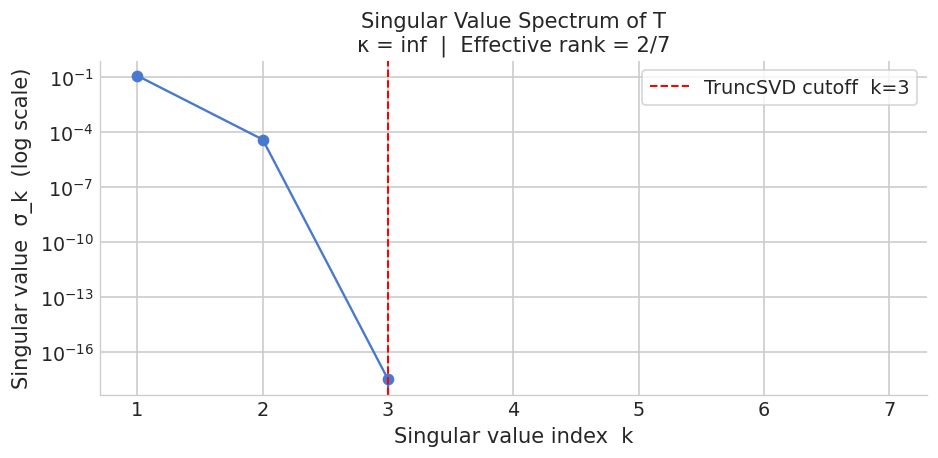

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_singular_values.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — MATRIX CONDITIONING DIAGNOSTICS
# What: Compute singular values, condition number and rank of T.
# Why:  Ill-conditioned T (high κ) means small noise in C blows up Q;
#       this motivates regularisation (Tikhonov, TruncSVD) in later blocks.
# ─────────────────────────────────────────────────────────────────────────────

U, s, Vt = svd(T_matrix, full_matrices=False)

cond_number = s[0] / s[-1]
effective_rank = int(np.sum(s > s[0] * 1e-6))

print("T matrix singular value decomposition:")
print(f"  Shape          : {T_matrix.shape}")
print(f"  Condition κ(T) : {cond_number:.2e}")
print(f"  Effective rank : {effective_rank} / {N}")


# Singular value spectrum plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(s) + 1), s, marker="o", color=PALETTE[0])
ax.set_xlabel("Singular value index  k")
ax.set_ylabel("Singular value  σ_k  (log scale)")
ax.set_title(f"Singular Value Spectrum of T\n"
             f"κ = {cond_number:.2e}  |  Effective rank = {effective_rank}/{N}")
ax.axvline(K_SVD, color="red", lw=1.2, ls="--", label=f"TruncSVD cutoff  k={K_SVD}")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_singular_values.png")
plt.show()
print(f"Saved: {ARTIFACT_DIR / 'fig_singular_values.png'}")


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — METHOD 1: LEAST SQUARES  (unconstrained)
# What: Solve C ≈ T·Q in the least-squares sense (minimum ||C − T·Q||₂).
# Why:  Baseline — no constraints, no regularisation.  Negative Q values are
#       physically meaningless but reveal the mathematical baseline.
# Solver: scipy.linalg.lstsq (LAPACK dgelsd driver — numerically stable).
# ─────────────────────────────────────────────────────────────────────────────

Q_lstsq, res_lstsq, rank_lstsq, sv_lstsq = lstsq(T_matrix, C_obs)

residual_lstsq = np.linalg.norm(C_obs - T_matrix @ Q_lstsq)
n_negative     = int((Q_lstsq < 0).sum())

print("Least Squares solution:")
print(f"  Residual ||C − TQ||₂ : {residual_lstsq:.4f}  µg m⁻³")
print(f"  Negative Q entries   : {n_negative} / {N}  (physically invalid)")
print(f"  Matrix rank (lstsq)  : {rank_lstsq}")


df_lstsq = pd.DataFrame(
    {"station": STATION_NAMES, "Q_lstsq [g/s]": Q_lstsq}
).set_index("station")
display(df_lstsq)


Least Squares solution:
  Residual ||C − TQ||₂ : 219.5329  µg m⁻³
  Negative Q entries   : 0 / 7  (physically invalid)
  Matrix rank (lstsq)  : 2


,Q_lstsq [g/s]
station,
BTMLayout,0.000000e+00
Hebbal,1.062460e+06
Jigani,1.025561e+03
KasturiNagar,1.180120e+02
RvceMailasandra,0.000000e+00
ShivapuraPeenya,0.000000e+00
SilkBoard,0.000000e+00


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — METHOD 2: NON-NEGATIVE LEAST SQUARES (NNLS)
# What: Constrain Q ≥ 0 — emission rates cannot be negative.
# Why:  Physical reality: a monitoring station cannot be a negative emitter.
#       NNLS is the minimum-residual solution subject to Q_i ≥ 0 for all i.
# Solver: scipy.optimize.nnls (Lawson-Hanson active-set algorithm).
# ─────────────────────────────────────────────────────────────────────────────

Q_nnls, rnorm_nnls = nnls(T_matrix, C_obs)

residual_nnls = np.linalg.norm(C_obs - T_matrix @ Q_nnls)
n_active      = int((Q_nnls > 0).sum())

print("NNLS solution:")
print(f"  Residual ||C − TQ||₂ : {residual_nnls:.4f}  µg m⁻³")
print(f"  Active sources       : {n_active} / {N}  (Q > 0)")
print(f"  Passive sources      : {N - n_active} / {N}  (Q = 0)")


df_nnls = pd.DataFrame(
    {"station": STATION_NAMES, "Q_nnls [g/s]": Q_nnls}
).set_index("station")
display(df_nnls)


NNLS solution:
  Residual ||C − TQ||₂ : 219.5329  µg m⁻³
  Active sources       : 2 / 7  (Q > 0)
  Passive sources      : 5 / 7  (Q = 0)


,Q_nnls [g/s]
station,
BTMLayout,0.000000e+00
Hebbal,1.062460e+06
Jigani,1.039141e+03
KasturiNagar,0.000000e+00
RvceMailasandra,0.000000e+00
ShivapuraPeenya,0.000000e+00
SilkBoard,0.000000e+00


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 — METHOD 3: TIKHONOV (RIDGE) REGULARISATION
# What: Penalise large Q by solving  min ||C − TQ||₂² + α||Q||₂².
# Why:  Ill-conditioned T amplifies noise in C.  L2 penalty shrinks Q toward
#       zero, stabilising the solution at the cost of some bias.
# Closed form:  Q = (Tᵀ T + αI)⁻¹ Tᵀ C
# ─────────────────────────────────────────────────────────────────────────────

TtT  = T_matrix.T @ T_matrix
TtC  = T_matrix.T @ C_obs
reg  = ALPHA_TIKHONOV * np.eye(N)
Q_tikh = np.linalg.solve(TtT + reg, TtC)

residual_tikh = np.linalg.norm(C_obs - T_matrix @ Q_tikh)
n_negative    = int((Q_tikh < 0).sum())

print(f"Tikhonov solution  (α = {ALPHA_TIKHONOV}):")
print(f"  Residual ||C − TQ||₂ : {residual_tikh:.4f}  µg m⁻³")
print(f"  Negative Q entries   : {n_negative} / {N}")


df_tikh = pd.DataFrame(
    {"station": STATION_NAMES, "Q_tikh [g/s]": Q_tikh}
).set_index("station")
display(df_tikh)


Tikhonov solution  (α = 0.001):
  Residual ||C − TQ||₂ : 223.8314  µg m⁻³
  Negative Q entries   : 0 / 7


,Q_tikh [g/s]
station,
BTMLayout,0.000000
Hebbal,1.733829
Jigani,960.079053
KasturiNagar,110.476896
RvceMailasandra,0.000000
ShivapuraPeenya,0.000000
SilkBoard,0.000000


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — METHOD 4: TRUNCATED SVD
# What: Keep only the top-k singular values; zero the rest.
# Why:  Small singular values correspond to noise modes that explode during
#       inversion.  Truncating at k removes these noisy directions.
# Formula:  T⁺_k = V_k Σ_k⁻¹ Uᵀ_k   →   Q = T⁺_k · C
# ─────────────────────────────────────────────────────────────────────────────

# U, s, Vt are already computed in Block 4
U_k  = U[:, :K_SVD]
s_k  = s[:K_SVD]
Vt_k = Vt[:K_SVD, :]

# Pseudo-inverse of the truncated system
T_pinv_k = Vt_k.T @ np.diag(1.0 / s_k) @ U_k.T
Q_svd    = T_pinv_k @ C_obs

residual_svd = np.linalg.norm(C_obs - T_matrix @ Q_svd)
n_negative   = int((Q_svd < 0).sum())

print(f"Truncated SVD solution  (k = {K_SVD}):")
print(f"  Retained energy      : {(s_k**2).sum() / (s**2).sum() * 100:.1f}%")
print(f"  Residual ||C − TQ||₂ : {residual_svd:.4f}  µg m⁻³")
print(f"  Negative Q entries   : {n_negative} / {N}")


df_svd = pd.DataFrame(
    {"station": STATION_NAMES, "Q_svd [g/s]": Q_svd}
).set_index("station")
display(df_svd)


Truncated SVD solution  (k = 3):
  Retained energy      : 100.0%
  Residual ||C − TQ||₂ : 227.8501  µg m⁻³
  Negative Q entries   : 1 / 7


,Q_svd [g/s]
station,
BTMLayout,0.000000e+00
Hebbal,1.062460e+06
Jigani,3.596945e+18
KasturiNagar,-3.125858e+19
RvceMailasandra,0.000000e+00
ShivapuraPeenya,0.000000e+00
SilkBoard,0.000000e+00


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 — RESIDUAL COMPARISON TABLE
# What: Side-by-side residuals and Q vectors for all four methods.
# Why:  Quick at-a-glance sanity check before plotting — if residuals diverge
#       hugely between methods, the problem is likely very ill-conditioned.
# ─────────────────────────────────────────────────────────────────────────────

methods_map = {
    "LeastSq"  : Q_lstsq,
    "NNLS"     : Q_nnls,
    "Tikhonov" : Q_tikh,
    "TruncSVD" : Q_svd,
}

residuals = {
    name: np.linalg.norm(C_obs - T_matrix @ Q)
    for name, Q in methods_map.items()
}

print("Residual comparison  ||C − T·Q||₂  per method:")
for name, r in residuals.items():
    bar = "█" * int(r / max(residuals.values()) * 30)
    print(f"  {name:12s}: {r:8.4f}  {bar}")



# Full Q comparison DataFrame
df_compare = pd.DataFrame(
    {f"Q_{name} [g/s]": Q for name, Q in methods_map.items()},
    index = pd.Index(STATION_NAMES, name="station"),
)
display(df_compare)


Residual comparison  ||C − T·Q||₂  per method:
  LeastSq     : 219.5329  ████████████████████████████
  NNLS        : 219.5329  ████████████████████████████
  Tikhonov    : 223.8314  █████████████████████████████
  TruncSVD    : 227.8501  ██████████████████████████████


,Q_LeastSq [g/s],Q_NNLS [g/s],Q_Tikhonov [g/s],Q_TruncSVD [g/s]
station,,,,
BTMLayout,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
Hebbal,1.062460e+06,1.062460e+06,1.733829,1.062460e+06
Jigani,1.025561e+03,1.039141e+03,960.079053,3.596945e+18
KasturiNagar,1.180120e+02,0.000000e+00,110.476896,-3.125858e+19
RvceMailasandra,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
ShivapuraPeenya,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
SilkBoard,0.000000e+00,0.000000e+00,0.000000,0.000000e+00


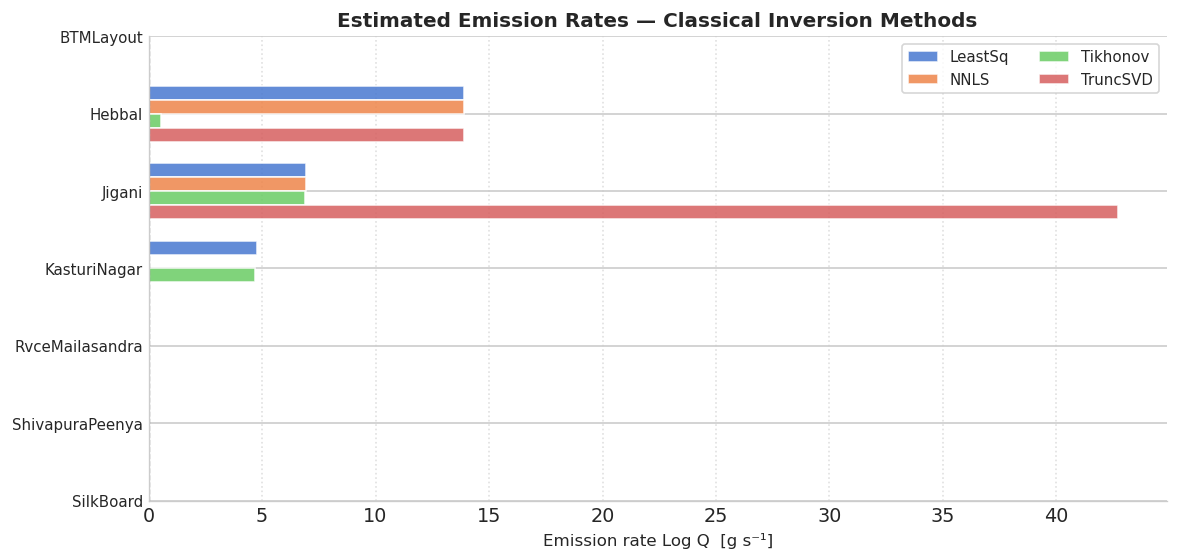

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_Q_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 — FIGURE 1: EMISSION RATES Q BY METHOD (FIXED ORIENTATION)
# What: Horizontal bar chart — one group per station, one bar per method.
# Why:  Shows where methods agree (high confidence) and disagree (ill-posed).
# ─────────────────────────────────────────────────────────────────────────────

method_labels = list(methods_map.keys())
n_methods = len(method_labels)
y = np.arange(N)
bar_h = 0.18  # This now represents the thickness of the horizontal rows

# Dynamic figure sizing based on active station count N
fig, ax = plt.subplots(figsize=(10, N * 0.55 + 1))

for k, (name, Q) in enumerate(methods_map.items()):
    # Calculate the vertical shift for each method within the station cluster
    offset = (k - n_methods / 2 + 0.5) * bar_h

    # ── CHANGES HERE ────────────────────────────────────────────────────────
    # 1. Changed ax.bar to ax.barh to force horizontal projection.
    # 2. y + offset now controls the vertical center-point of each horizontal bar.
    # 3. np.log(Q) is the horizontal width stretching out along the X-axis.
    # 4. Passed height=bar_h explicitly to handle bar thickness.
    # ────────────────────────────────────────────────────────────────────────
    ax.barh(
        y + offset, np.log(Q), height=bar_h, label=name, color=PALETTE[k], alpha=0.85
    )

# Clean up the Y-axis coordinates to display station names beautifully
ax.set_yticks(y)
ax.set_yticklabels(STATION_NAMES, fontsize=9)
ax.invert_yaxis()  # Keeps your first station at the top of the chart instead of the bottom

# Label and clean up the visual scale
ax.set_xlabel("Emission rate Log Q  [g s⁻¹]", fontsize=10)
ax.set_title(
    "Estimated Emission Rates — Classical Inversion Methods",
    fontsize=12,
    fontweight="bold",
)
ax.axvline(0, color="gray", lw=0.8, ls="--")  # Grid alignment marker at log(1) = 0
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(
    axis="x", linestyle=":", alpha=0.6
)  # Add faint vertical grid lines for tracking scale

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_Q_comparison.png", dpi=300)
plt.show()
print(f"Saved: {ARTIFACT_DIR / 'fig_Q_comparison.png'}")

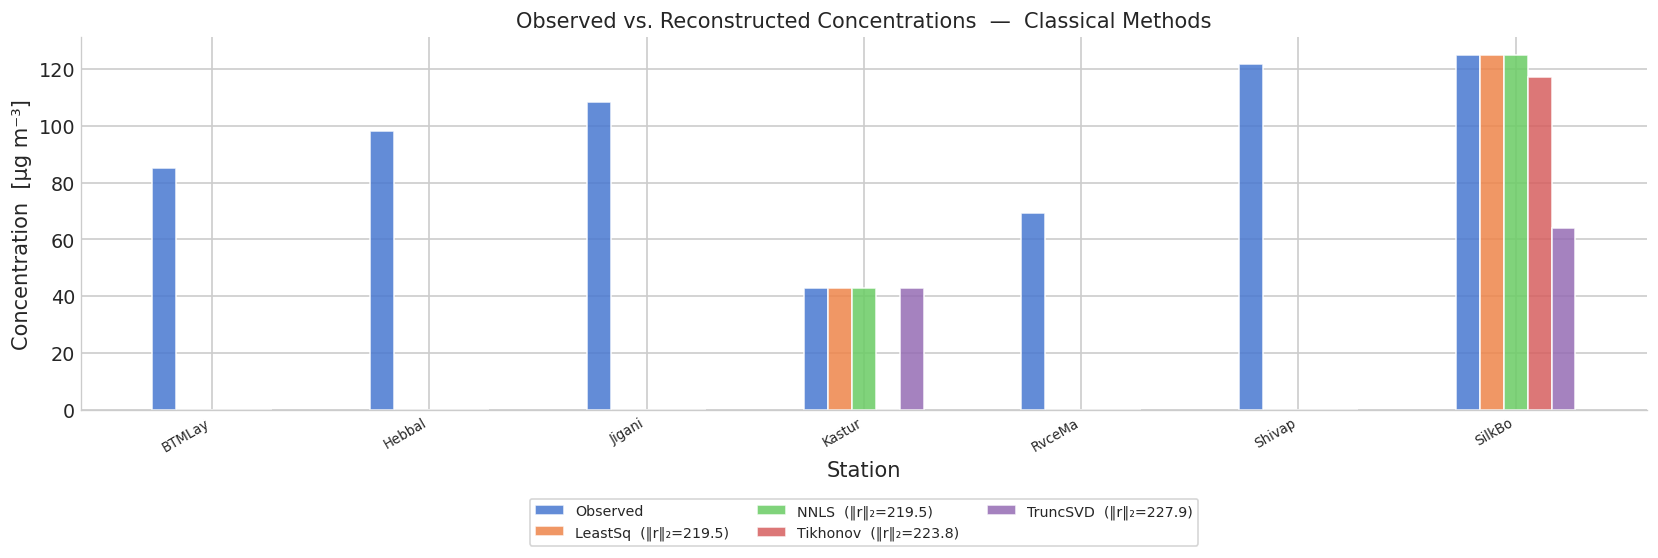

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_reconstruction.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 — FIGURE 2: OBSERVED vs. RECONSTRUCTED CONCENTRATIONS
# What: C_reconstructed = T·Q for each method vs. C_obs.
# Why:  Visual residual check — how well does each Q explain the data?
#       Systematic over/under-estimation points to model deficiencies.
# ─────────────────────────────────────────────────────────────────────────────

C_reconstructed = {"Observed": C_obs}
for name, Q in methods_map.items():
    C_reconstructed[name] = T_matrix @ Q

all_methods = list(C_reconstructed.keys())
n_all = len(all_methods)
x     = np.arange(N)
bw    = 0.11

fig, ax = plt.subplots(figsize=(14, 5))

for k, method in enumerate(all_methods):
    vals = C_reconstructed[method]
    if method != "Observed":
        resid = np.linalg.norm(C_obs - vals)
        label = f"{method}  (‖r‖₂={resid:.1f})"
    else:
        label = "Observed"
    ax.bar(
        x + (k - n_all / 2 + 0.5) * bw, vals, width=bw,
        label=label, color=PALETTE[k % len(PALETTE)], alpha=0.85
    )

ax.set_xticks(x)
ax.set_xticklabels([s[:6] for s in STATION_NAMES], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Concentration  [µg m⁻³]")
ax.set_xlabel("Station")
ax.set_title("Observed vs. Reconstructed Concentrations  —  Classical Methods")
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=3, fontsize=8.5, frameon=True
)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_reconstruction.png")
plt.show()
print(f"Saved: {ARTIFACT_DIR / 'fig_reconstruction.png'}")


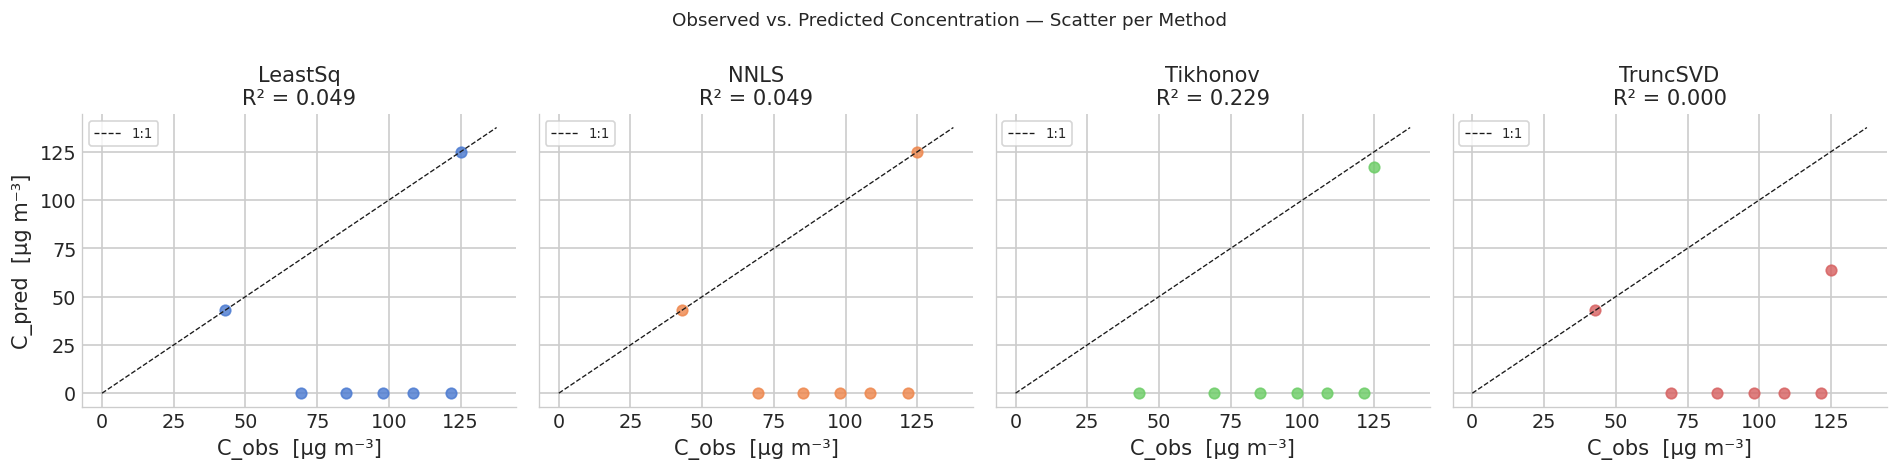

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_scatter_methods.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12 — FIGURE 3: SCATTER — OBSERVED vs. PREDICTED (per method)
# What: Scatter of C_obs vs. C_predicted for each method with 1:1 reference.
# Why:  Points on the diagonal = perfect fit; systematic deviations reveal
#       bias (intercept) or scale error (slope ≠ 1).
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, n_methods, figsize=(4 * n_methods, 4), sharey=True)

for k, (name, Q) in enumerate(methods_map.items()):
    ax = axes[k]
    C_pred = T_matrix @ Q
    ax.scatter(C_obs, C_pred, color=PALETTE[k], s=40, alpha=0.8)
    lim = max(C_obs.max(), C_pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
    ax.set_xlabel("C_obs  [µg m⁻³]")
    ax.set_ylabel("C_pred  [µg m⁻³]") if k == 0 else None
    r2 = np.corrcoef(C_obs, C_pred)[0, 1] ** 2
    ax.set_title(f"{name}\nR² = {r2:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("Observed vs. Predicted Concentration — Scatter per Method", fontsize=11)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_scatter_methods.png")
plt.show()
print(f"Saved: {ARTIFACT_DIR / 'fig_scatter_methods.png'}")


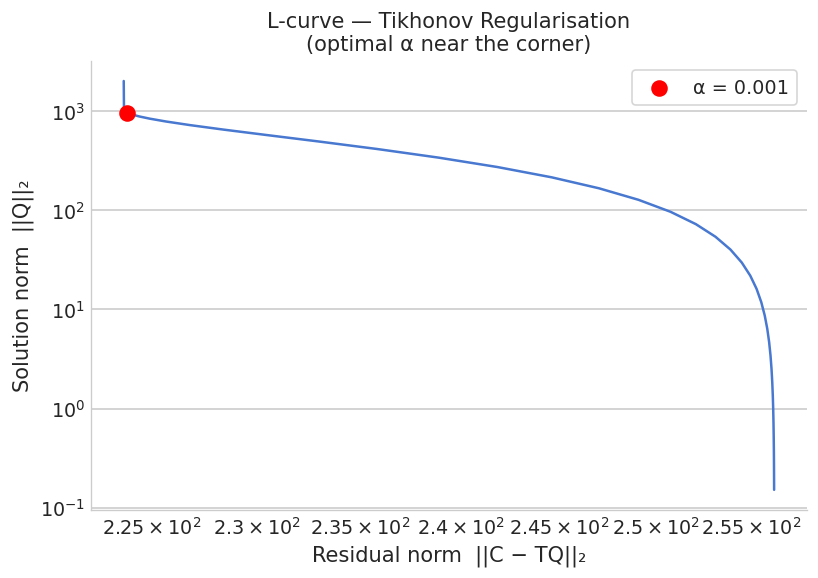

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_lcurve.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 13 — TIKHONOV ALPHA SWEEP (L-curve)
# What: Solve Tikhonov for a range of α values; plot ||C−TQ|| vs ||Q|| (L-curve).
# Why:  The "corner" of the L-curve is the optimal α — balancing data fit and
#       solution norm.  Useful for picking ALPHA_TIKHONOV in Block 2.
# ─────────────────────────────────────────────────────────────────────────────

alphas      = np.logspace(-6, 2, 60)
resid_norms = []
sol_norms   = []

TtT_base = T_matrix.T @ T_matrix
TtC_base = T_matrix.T @ C_obs

for a in alphas:
    Q_a = np.linalg.solve(TtT_base + a * np.eye(N), TtC_base)
    resid_norms.append(np.linalg.norm(C_obs - T_matrix @ Q_a))
    sol_norms.append(np.linalg.norm(Q_a))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(resid_norms, sol_norms, color=PALETTE[0], lw=1.5)

# Mark the chosen alpha
Q_chosen = np.linalg.solve(TtT_base + ALPHA_TIKHONOV * np.eye(N), TtC_base)
r_chosen = np.linalg.norm(C_obs - T_matrix @ Q_chosen)
s_chosen = np.linalg.norm(Q_chosen)
ax.scatter([r_chosen], [s_chosen], color="red", s=80, zorder=5, label=f"α = {ALPHA_TIKHONOV}")

ax.set_xlabel("Residual norm  ||C − TQ||₂")
ax.set_ylabel("Solution norm  ||Q||₂")
ax.set_title("L-curve — Tikhonov Regularisation\n(optimal α near the corner)")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_lcurve.png")
plt.show()
print(f"Saved: {ARTIFACT_DIR / 'fig_lcurve.png'}")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 14 — SAVE RESULTS AS PARQUET
# What: Persist all Q estimates and residuals to parquet for downstream use.
# Why:  Parquet preserves column names and index; easily read in any notebook
#       or script without re-running the solvers.
# ─────────────────────────────────────────────────────────────────────────────

# Full Q comparison table
df_Q_all = pd.DataFrame(
    {
        "Q_lstsq [g/s]": Q_lstsq,
        "Q_nnls [g/s]": Q_nnls,
        "Q_tikh [g/s]": Q_tikh,
        "Q_svd [g/s]": Q_svd,
    },
    index=pd.Index(STATION_NAMES, name="station_name"),
)
df_Q_all.to_parquet(ARTIFACT_DIR / "Q_classical_solutions.parquet")
print(f"Q_classical_solutions.parquet  {df_Q_all.shape}")
display(df_Q_all)

# Residuals
df_residuals = pd.DataFrame(
    {"method": list(residuals.keys()), "residual_L2": list(residuals.values())}
)
df_residuals.to_parquet(ARTIFACT_DIR / "residuals_classical.parquet")
print(f"residuals_classical.parquet   {df_residuals.shape}")
display(df_residuals)

# Reconstructed concentrations
df_C_recon = pd.DataFrame(
    {name: C_reconstructed[name] for name in all_methods},
    index=pd.Index(STATION_NAMES, name="station_name"),
)
df_C_recon.to_parquet(ARTIFACT_DIR / "C_reconstructed.parquet")
print(f"C_reconstructed.parquet       {df_C_recon.shape}")
print("CLASSICAL SOLVER SUMMARY")
for name, r in sorted(residuals.items(), key=lambda x: x[1]):
    print(f"  {name:12s}  ||r||₂ = {r:.4f}  µg m⁻³")

Q_classical_solutions.parquet  (7, 4)


,Q_lstsq [g/s],Q_nnls [g/s],Q_tikh [g/s],Q_svd [g/s]
station_name,,,,
BTMLayout,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
Hebbal,1.062460e+06,1.062460e+06,1.733829,1.062460e+06
Jigani,1.025561e+03,1.039141e+03,960.079053,3.596945e+18
KasturiNagar,1.180120e+02,0.000000e+00,110.476896,-3.125858e+19
RvceMailasandra,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
ShivapuraPeenya,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
SilkBoard,0.000000e+00,0.000000e+00,0.000000,0.000000e+00


residuals_classical.parquet   (4, 2)


,method,residual_L2
0,LeastSq,219.532884
1,NNLS,219.532884
2,Tikhonov,223.831428
3,TruncSVD,227.850142


C_reconstructed.parquet       (7, 5)
CLASSICAL SOLVER SUMMARY
  LeastSq       ||r||₂ = 219.5329  µg m⁻³
  NNLS          ||r||₂ = 219.5329  µg m⁻³
  Tikhonov      ||r||₂ = 223.8314  µg m⁻³
  TruncSVD      ||r||₂ = 227.8501  µg m⁻³
